# **Modelo de Média Móvel**


* **Conceituação:** Modelo onde o valor $Y_t$ depende da média da série acrescida de uma combinação linear dos erros de previsão passados (choques ou ruídos).

* **Equação Matemática:** $Y_t = \mu + \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \dots + \theta_q \epsilon_{t-q}$

* **Quando utilizar:** A série temporal é estacionária.

* O gráfico **ACF** apresenta um corte abrupto após o lag $q$.
*  O gráfico **PACF** decai suavemente.
*   Situações em que eventos aleatórios pontuais afetam o sistema por um curto período de tempo (ex: retornos de ações após um choque de notícias).

# **Criandoa série temporal**

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from  matplotlib.pylab import rcParams
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

## **Definição da série temporal**

In [41]:
np.random.seed(42)
n = 100
erros = np.random.normal(0, 1, n)
y_ma = [erros[0]]
for t in range(1, n):
    y_ma.append(erros[t] + 0.8 * erros[t-1])

serie_media_movel = pd.Series(y_ma, index=pd.date_range('2024-01-01', periods=n, freq='D'))

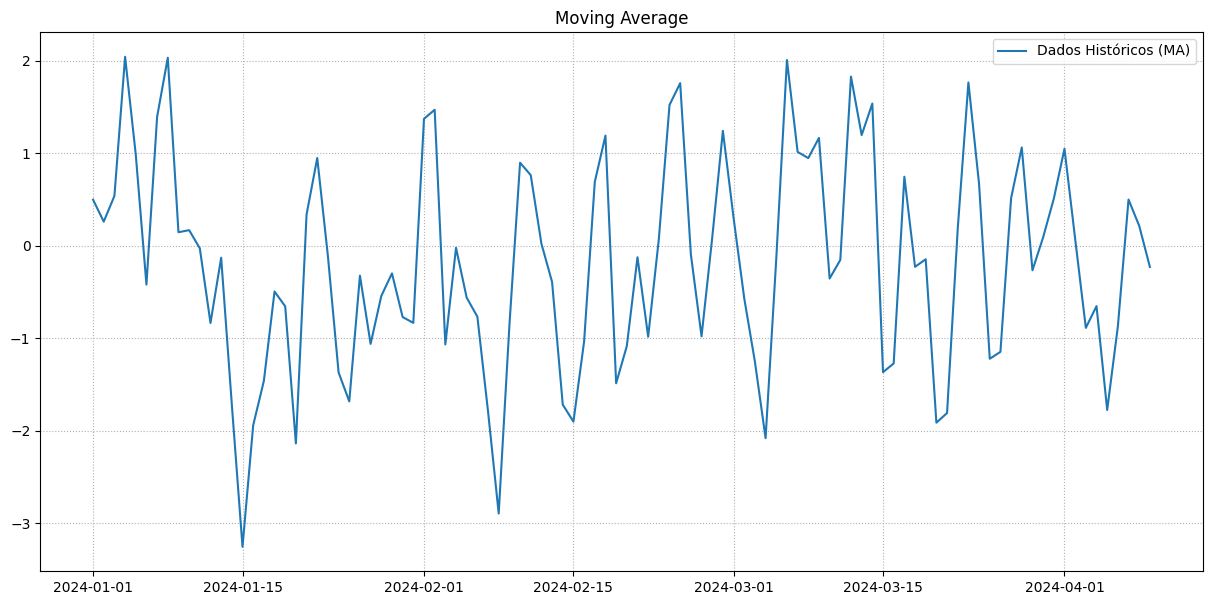

In [42]:
# Gráfico
plt.figure(figsize=(15, 7))
plt.plot(serie_media_movel, label='Dados Históricos (MA)')
plt.title('Moving Average')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

# **Estudo da Série temporal**
Nesta seção será realizdo o estudo da série temporal, onde serão avaliados:

* Decomposição

* Normalidade da série.
  * Teste de Shapiro-Wilk
  * Grafico QQ_plot
  * Histograma
* Estacionariadade (Teste KPSS)
* Funções de auto correlação (ACF e PACF)

### **Decomposicao**

In [43]:
decomposicao = seasonal_decompose(serie_media_movel, model='additive')

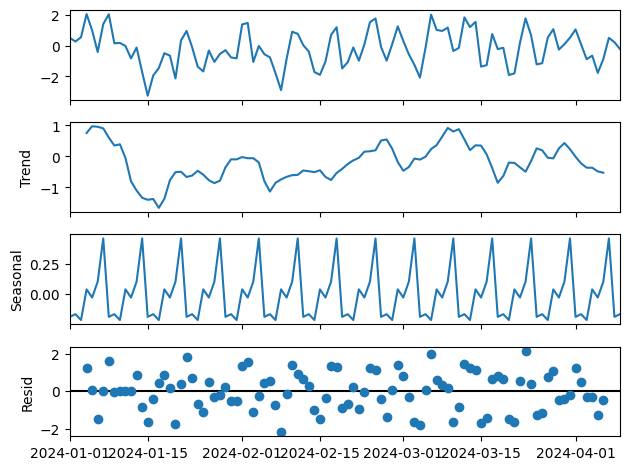

In [44]:
decomposicao.plot()
plt.show()

## **Normalidade da série.**

### **Hipóteses do Teste de Shapiro-Wilk**


O teste avalia duas hipóteses concorrentes:
* **Hipótese Nula ($H_0$):** Os dados seguem uma distribuição normal.
* **Hipótese Alternativa ($H_1$):** Os dados não seguem uma distribuição normal.

**Como Interpretar o P-Valor (p-value)**

* **Se $p \ge 0,05$:** Não há evidências para rejeitar $H_0$. Conclui-se que os resíduos do modelo são aproximadamente normais (modelo validado quanto à normalidade).
* **Se $p < 0,05$:** Rejeita-se $H_0$. Os resíduos não seguem uma distribuição normal, indicando possíveis problemas no modelo (como presenças de outliers ou heterocedasticidade

In [45]:
import scipy.stats as stats

e,p_valor =stats.shapiro(serie_media_movel)
print('Estatistica de teste = %.3f, p-valor = %.3f' % (e,p_valor))

Estatistica de teste = 0.988, p-valor = 0.520


In [46]:
if p_valor >= 0.05:
  print('Não há evidências para rejeitar a hipótese nula. Os dados seguem uma distribuição normal.')
else:
  print('Rejeita-se a hipótese nula. Os dados não seguem uma distribuição normal.')

Não há evidências para rejeitar a hipótese nula. Os dados seguem uma distribuição normal.


### **QQ_plot**

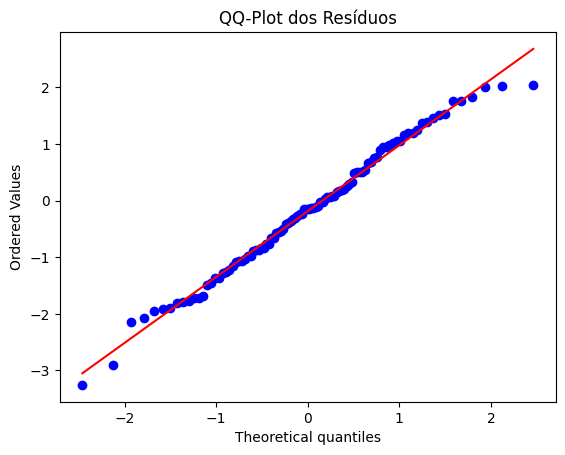

In [47]:
import scipy.stats as stats
stats.probplot(serie_media_movel, dist='norm', plot=plt)
plt.title('QQ-Plot dos Resíduos')
plt.show()

### **Histrograma da série**

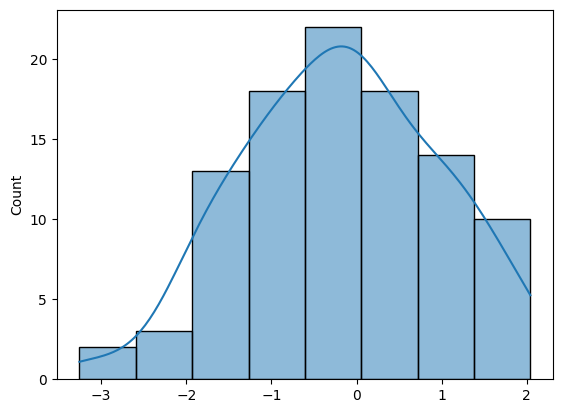

In [48]:
import seaborn as sns
sns.histplot(serie_media_movel, kde=True)
plt.show()

## **Estacionaridade da série -Modelo Autoregressivo AR(p)**

O teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin) é um teste estatístico utilizado em séries temporais para verificar se os dados são estacionários em torno de uma média ou de uma tendência determinística.

**Como o Teste Funciona**
* **Hipótese Nula (H₀):** A série temporal é estacionária (em nível ou em tendência).
* **Hipótese Alternativa (H₁):** A série temporal não é estacionária (possui raiz unitária

**Interpretação dos Resultados**
* **p-valor > 0,05** (ou estatística menor que o valor crítico): Você não rejeita a hipótese nula. Os dados indicam que a série é estacionária.
* **p-valor ≤ 0,05** (ou estatística maior que o valor crítico): Você rejeita a hipótese nula. Há fortes evidências de que a série não é estacionár


In [49]:
import statsmodels.tsa.stattools

In [50]:
result_kpss = statsmodels.tsa.stattools.kpss(serie_media_movel)
print('Estatistica de teste = %.3f, p-valor = %.3f' % (result_kpss[0], result_kpss[1]))

Estatistica de teste = 0.148, p-valor = 0.100


/tmp/ipykernel_521/69480934.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  result_kpss = statsmodels.tsa.stattools.kpss(serie_media_movel)
/tmp/ipykernel_521/69480934.py:1: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_kpss = statsmodels.tsa.stattools.kpss(serie_media_movel)


In [51]:
if p_valor > 0.05:
    print('A série é estacionária')
else:
    print('A série não é estacionária')

A série é estacionária


##  **Estudo da autocorrelaçao (ACF e PACF)**

In [52]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

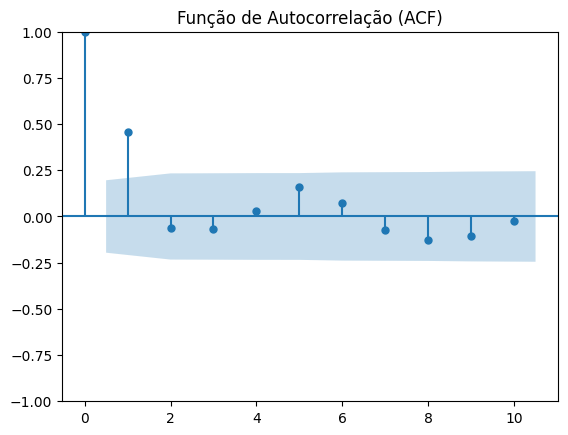

In [53]:
plot_acf(serie_media_movel ,lags=10, color='#1f77b4', title='Função de Autocorrelação (ACF)')
plt.show()

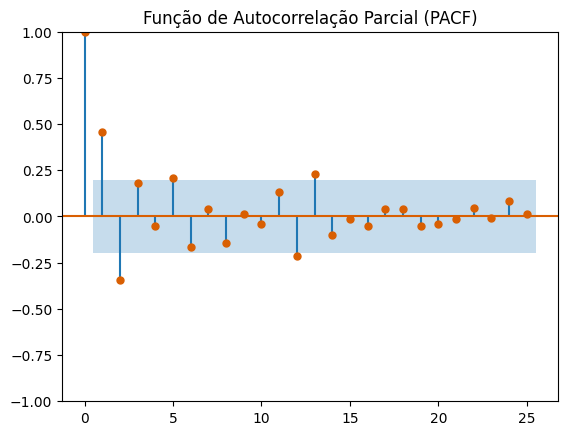

In [54]:
plot_pacf(serie_media_movel, lags=25, color='#d95f02', title='Função de Autocorrelação Parcial (PACF)')
plt.show()

# **Implementação do modelo  média movel**

* Definição do modelo
* Estudo do resíduo
* Aplicação do modelo.

## **Definição do modelo médiamóvel**

In [55]:
from statsmodels.tsa.arima.model import ARIMA

In [56]:
modelo_media_movel= ARIMA(serie_media_movel, order=(0, 0, 4))

In [57]:
modelo_media_movel_result = modelo_media_movel.fit()

In [58]:
print (modelo_media_movel_result.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(0, 0, 4)   Log Likelihood                -130.688
Date:                Thu, 17 Sep 2026   AIC                            273.376
Time:                        18:42:59   BIC                            289.007
Sample:                    01-01-2024   HQIC                           279.702
                         - 04-09-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1862      0.151     -1.233      0.217      -0.482       0.110
ma.L1          0.8069      0.105      7.697      0.000       0.601       1.012
ma.L2         -0.0360      0.154     -0.233      0.8

## **Estudo do resíduo.**

In [59]:
residuos_modelo_media_movel = modelo_media_movel_result.resid

In [60]:
print(f'Média dos resíduos =,  {residuos_modelo_media_movel .mean():.5f}')
print(f'Desvio padrão dos resíduos =,  {residuos_modelo_media_movel .std():.5f}')


Média dos resíduos =,  0.00290
Desvio padrão dos resíduos =,  0.89730


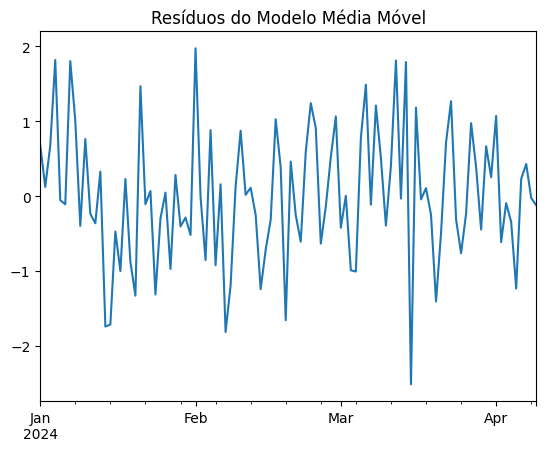

In [61]:
residuos_modelo_media_movel.plot()
plt.title('Resíduos do Modelo Média Móvel')
plt.show()

###  **Normalidade do resíduo**

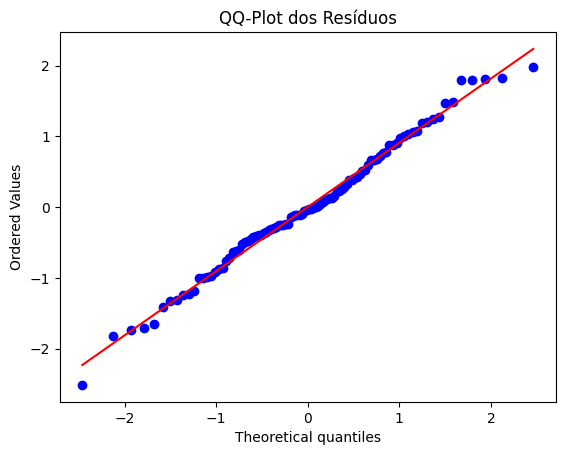

In [62]:
stats.probplot(residuos_modelo_media_movel, dist='norm', plot=plt)
plt.title('QQ-Plot dos Resíduos')
plt.show()

### **Autocorrelação dos resíduos**

In [63]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# 'residuos' é a série temporal dos erros do modelo
resultado = acorr_ljungbox(residuos_modelo_media_movel, lags=[10], return_df=True)
print(resultado)

     lb_stat  lb_pvalue
10  3.617112   0.962971


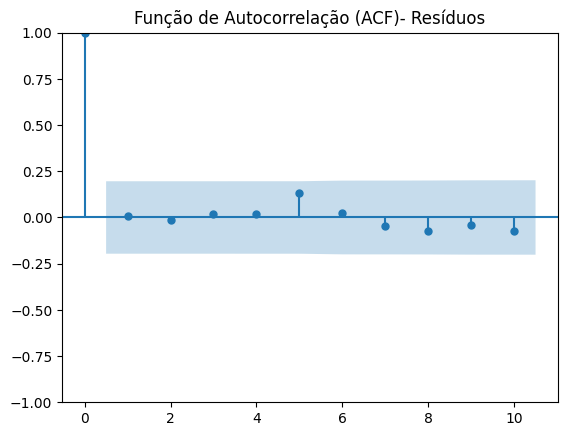

In [64]:
plot_acf(residuos_modelo_media_movel,lags=10, color='#1f77b4', title='Função de Autocorrelação (ACF)- Resíduos')
plt.show()

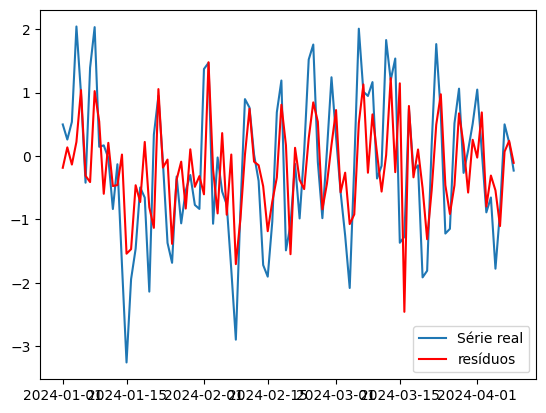

In [65]:
plt.plot(serie_media_movel, label  ="Série real")
plt.plot(serie_media_movel-residuos_modelo_media_movel, color ='red', label ="resíduos")
plt.legend(loc = 'best')
plt.show()

# **Aplicando o modelo médiamóvel**

In [66]:
modelo_media_movel_result.fittedvalues

,0
2024-01-01,-0.186191
2024-01-02,0.135368
2024-01-03,-0.135438
2024-01-04,0.222003
2024-01-05,1.038011
...,...
2024-04-05,-0.542562
2024-04-06,-1.105284
2024-04-07,0.067883
2024-04-08,0.238230


In [67]:
previsao_modelo_media_movel = modelo_media_movel_result.forecast(10)

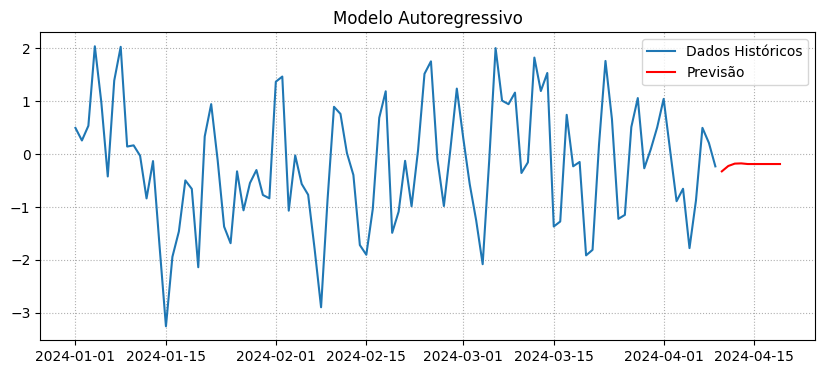

In [68]:
plt.figure(figsize=(10, 4))
plt.plot(serie_media_movel, label='Dados Históricos')
plt.plot(previsao_modelo_media_movel, color='red', label='Previsão')
plt.title('Modelo Autoregressivo')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

## **Criando os intervalor de confiança para as previsões**

In [69]:
previsao_modelo_media_movel  = modelo_media_movel_result.get_forecast(steps=7).summary_frame()

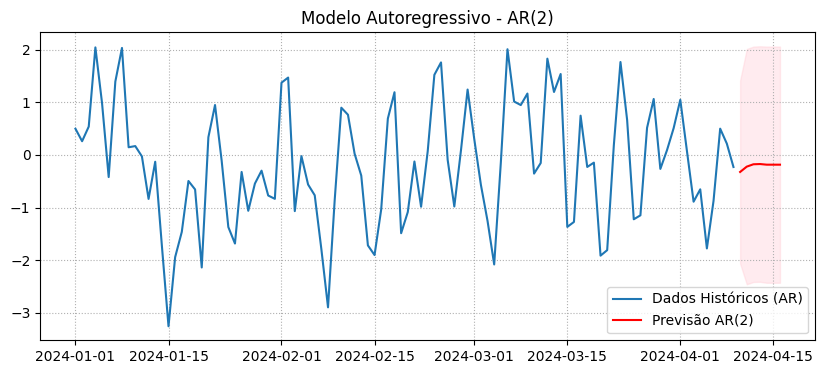

In [70]:
plt.figure(figsize=(10, 4))
plt.plot(serie_media_movel, label='Dados Históricos (AR)')
plt.plot(previsao_modelo_media_movel['mean'], color='red', label='Previsão AR(2)')
plt.fill_between(previsao_modelo_media_movel.index, previsao_modelo_media_movel['mean_ci_lower'], previsao_modelo_media_movel['mean_ci_upper'], color='pink', alpha=0.3)
plt.title('Modelo Autoregressivo - AR(2)')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()